# **DATA 543 Spring 2026: CA Energy Prices**

In [52]:
#### DATA 543 Testing Code ####
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datetime import timedelta
import matplotlib.pyplot as plt
import warnings

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [53]:
###################################################################
# Import Data from the Github Repo and Clean + Format
###################################################################

base_path = 'Local Data/'
start_date = '2010-01-09'
end_date = '2025-12-31'

df_localtemps = pd.read_csv(base_path +'local_weather.csv') #daily temp observations, precipitation at Shasta Dam
df_localtemps = df_localtemps.drop(columns=['STATION', 'NAME', 'DAPR', 'MDPR', 'SNOW', 'SNWD'])
df_localtemps['DATE'] = pd.to_datetime(df_localtemps['DATE'], format='mixed')
df_localtemps.columns = ['Date', 'Precipitation', 'Max Temp (F)', 'Min Temp (F)', 'Observed Temp (F)']
df_localtemps = df_localtemps.set_index('Date').sort_index()

df_hdd_cdd = pd.read_csv(base_path + 'hdd_cdd.csv') #monthly hdd and cdd
df_hdd_cdd['Date'] = pd.to_datetime(df_hdd_cdd['Date'], format='%Y%m')
df_hdd_cdd = df_hdd_cdd.set_index('Date').sort_index()
df_hdd_cdd = df_hdd_cdd.resample('D').ffill() #fill out monthly data to days

df_ONI = pd.read_csv(base_path + 'Monthly Oceanic Nino Index (ONI) - Long.csv') #monthly
df_ONI['Date'] = pd.to_datetime(dict(year=df_ONI['Year'], month=df_ONI['MonthNum'], day=1)) #dataframe ends 12-01-2025 not 12-31 so need to manually add the extra days so that there are no NaN entries to the model
df_ONI = df_ONI.set_index('Date').sort_index()
df_ONI = df_ONI.drop(columns = ['Year', 'MonthTxt', 'MonthNum'])
last = df_ONI.index.max()
next_month = last + pd.offsets.MonthBegin(1)
df_ONI.loc[next_month] = df_ONI.loc[last]
df_ONI = df_ONI.resample('D').ffill()
df_ONI.columns = ['ONI']

df_pricedata = pd.read_csv(base_path + 'price_data.csv')
df_pricedata.columns = ['Date', 'PX_LAST', 'Lag [t-1]', 'Lag [t-7]', 'Rolling Average [7d]', 'Rolling Average [30d]', 'NatGas Lag [t-1]', 'NatGas Lag [t-7]', 'NatGas Rolling [7d]', 'NatGas Rolling [30d]', 'NatGas Rolling 2 [30d]'] #temporary we can name these whatever evenutally
df_pricedata['Date'] = pd.to_datetime(df_pricedata['Date'], format='%m/%d/%Y')
df_pricedata = df_pricedata.set_index('Date').sort_index()
df_pricedata = df_pricedata.drop(columns = ['NatGas Rolling 2 [30d]'])

df_1day_load = pd.read_csv(base_path + 'caiso_load_forecast_daily_2010_2026.csv')
df_1day_load['date'] = pd.to_datetime(df_1day_load['date'], format='mixed')
df_1day_load.columns = ['Date', 'Mean Hourly Forecast [MW]', 'Max Hourly Forecast [MW]', 'Min Hourly Forecast [MW]']
df_1day_load = df_1day_load.set_index('Date').sort_index()
#print(df_1day_load.shape[0])

df_7day_load = pd.read_csv(base_path + 'caiso_tac_7day_load_forecast_daily_2010_2026.csv')
df_7day_load['date'] = pd.to_datetime(df_7day_load['date'], format='mixed')
df_7day_load['date'] = df_7day_load['date'] - timedelta(weeks = 1)
df_7day_load = df_7day_load.drop(columns=['pge_7day_load_forecast_hours', 'first_publish_time', 'last_publish_time'])
df_7day_load.columns = ['Date', 'Week-Ahead Mean Daily Forecast [MW]', 'Week-Ahead Max Daily Forecast [MW]', 'Week-Ahead Min Daily Forecast [MW]']
df_7day_load = df_7day_load.set_index('Date').sort_index()
#print(df_7day_load.shape[0])

dfs = [df_hdd_cdd, df_ONI, df_localtemps, df_pricedata, df_1day_load, df_7day_load] #add new dataframes here

####################################################################################
# double check no duplicates, aligned indexes, etc. to prepare for splice and join
####################################################################################

cleaned = []
for df in dfs:
    df = df.copy()
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df[~df.index.isna()]
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]
    cleaned.append(df)
dfs = cleaned
dfs = [df.loc[start_date:end_date] for df in dfs]
df_hdd_cdd, df_ONI, df_localtemps, df_pricedata, df_1day_load, df_7day_load = dfs

    
dfs = [df.loc[start_date:end_date] for df in dfs]
df_hdd_cdd, df_ONI, df_localtemps, df_pricedata, df_1day_load, df_7day_load = dfs #add back in any new dataframes

####################################################################################
# Final Concatenation, Formatting to feed into ML models
####################################################################################

monthly_df_list = [df_hdd_cdd, df_ONI]
daily_df_list = [df_pricedata, df_localtemps]
load_df_list = [df_1day_load, df_7day_load]

df_monthly = pd.concat(monthly_df_list, axis=1, join='outer') #join into seperate sets for later
df_daily = pd.concat(daily_df_list, axis=1, join='outer')
df_load = pd.concat(load_df_list, axis = 1, join = 'outer')

###df_load fix for datetime duplicate error
manual_rows = {"2014-11-26": [25245.268, 29913.52, 19864.41],"2018-09-09": [28060.909, 35389.44, 22421.09],"2018-09-26": [27511.411, 33713.98, 21236.35],"2018-09-27": [29351.431, 36329.69, 22088.29]}
cols = ["Week-Ahead Mean Daily Forecast [MW]", "Week-Ahead Max Daily Forecast [MW]", "Week-Ahead Min Daily Forecast [MW]"]
for d, vals in manual_rows.items(): df_load.loc[pd.Timestamp(d), cols] = vals
df_load = df_load.sort_index()

n_vars_monthly = df_monthly.shape[1] #variable so we don't have to mess with stuff in the model as we add stuff
n_vars_daily = df_daily.shape[1]
n_vars_load = df_load.shape[1]

df_load_daily_combined = pd.concat([df_daily, df_load], axis = 1, join = 'outer')
combined_df = pd.concat([df_monthly, df_daily], axis = 1, join = 'outer') #one total dataframe

**Dataframes**

In [54]:
df_daily

,PX_LAST,Lag [t-1],Lag [t-7],Rolling Average [7d],Rolling Average [30d],NatGas Lag [t-1],NatGas Lag [t-7],NatGas Rolling [7d],NatGas Rolling [30d],Precipitation,Max Temp (F),Min Temp (F),Observed Temp (F)
Date,,,,,,,,,,,,,
2010-01-09,48.46,55.16,45.14,51.217143,50.457500,5.92,5.92,6.248,6.248000,0.16,47.0,41.0,45.897837
2010-01-10,48.37,48.46,50.90,50.855714,50.225556,5.92,5.92,6.248,6.248000,0.05,54.0,45.0,46.086377
2010-01-11,53.43,48.37,50.21,51.315714,50.546000,5.85,5.95,6.182,6.193333,0.00,56.0,42.0,43.103282
2010-01-12,52.36,53.43,51.60,51.424286,50.710909,5.90,6.11,6.100,6.144286,0.95,50.0,43.0,45.168006
2010-01-13,49.04,52.36,49.69,51.331429,50.571667,6.07,6.03,6.042,6.113750,2.57,52.0,45.0,47.043405
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,17.35,30.33,0.00,21.834286,38.462000,3.00,2.24,2.410,3.486923,1.90,56.0,35.0,35.000000
2025-12-28,17.35,17.35,0.00,24.312857,37.372000,3.00,2.24,2.410,3.486923,0.00,50.0,35.0,44.909204
2025-12-29,33.23,17.35,0.00,29.060000,36.798000,3.00,2.24,2.300,3.486923,0.00,56.0,43.0,46.998529


In [55]:
df_monthly

,HDD (F),CDD (F),ONI
Date,,,
2010-01-09,492,0,1.3
2010-01-10,492,0,1.3
2010-01-11,492,0,1.3
2010-01-12,492,0,1.3
2010-01-13,492,0,1.3
...,...,...,...
2025-12-27,358,5,-0.5
2025-12-28,358,5,-0.5
2025-12-29,358,5,-0.5


In [56]:
df_load

,Mean Hourly Forecast [MW],Max Hourly Forecast [MW],Min Hourly Forecast [MW],Week-Ahead Mean Daily Forecast [MW],Week-Ahead Max Daily Forecast [MW],Week-Ahead Min Daily Forecast [MW]
Date,,,,,,
2010-01-09,23281.458333,27557.00,19591.00,23292.625000,27524.00,19699.50
2010-01-10,22432.000000,27414.00,18946.00,22416.979167,27328.50,19381.00
2010-01-11,25120.354167,30091.50,18970.00,24925.229167,29954.50,19441.50
2010-01-12,25317.250000,30006.50,19608.00,25856.583333,30724.00,19925.50
2010-01-13,25259.104167,30054.50,19597.50,26131.291667,30891.00,20365.50
...,...,...,...,...,...,...
2025-12-27,20500.366250,24190.48,16654.74,21503.538333,25034.40,18844.52
2025-12-28,20407.457917,25055.89,15305.02,21499.080417,25381.66,19187.00
2025-12-29,22993.606667,27599.08,19685.22,23935.740000,27748.36,19463.93


**Machine Learning Models and Figures**

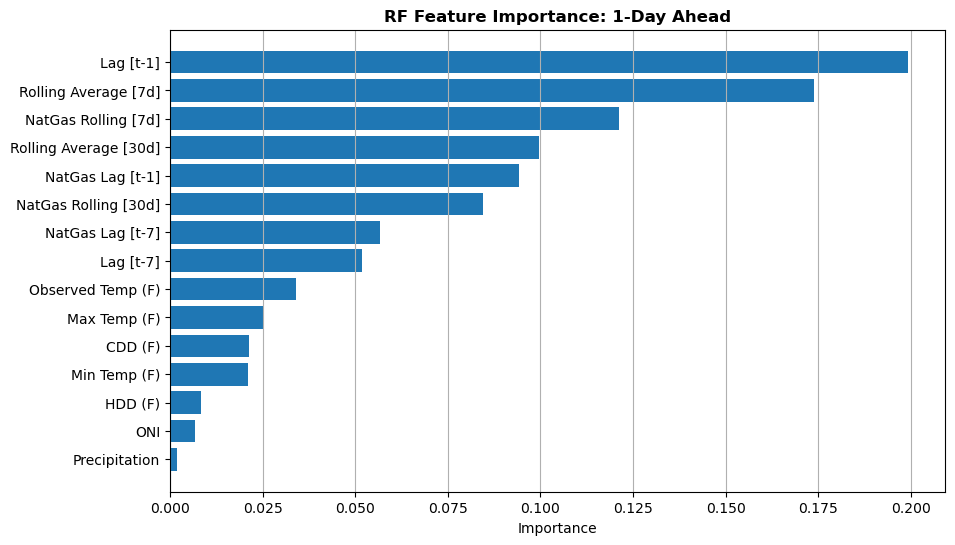

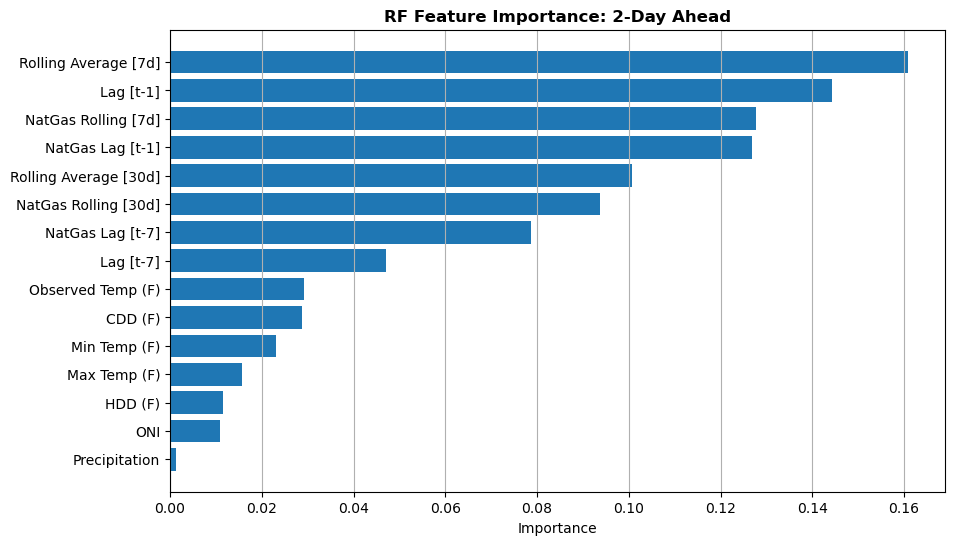

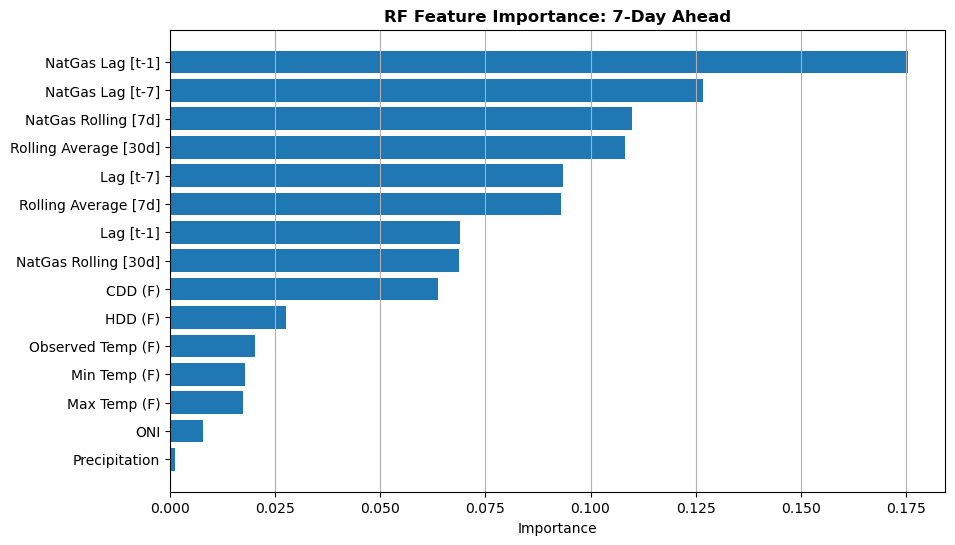

Epoch 01 | Train Loss: 389.6810 | Val Loss: 1414.6818
Epoch 02 | Train Loss: 292.0104 | Val Loss: 1326.4616
Epoch 03 | Train Loss: 283.5269 | Val Loss: 1287.8571
Epoch 04 | Train Loss: 279.4319 | Val Loss: 1259.2249
Epoch 05 | Train Loss: 276.0017 | Val Loss: 1263.2758
Epoch 06 | Train Loss: 273.0359 | Val Loss: 1277.2402
Epoch 07 | Train Loss: 270.3503 | Val Loss: 1300.9837
Epoch 08 | Train Loss: 267.4212 | Val Loss: 1319.2096
Epoch 09 | Train Loss: 265.3232 | Val Loss: 1321.9280
Epoch 10 | Train Loss: 260.9276 | Val Loss: 1330.3518
Epoch 11 | Train Loss: 258.1840 | Val Loss: 1340.1467
Epoch 12 | Train Loss: 255.3613 | Val Loss: 1288.9357
Epoch 13 | Train Loss: 250.2893 | Val Loss: 1215.4798
Epoch 14 | Train Loss: 249.7836 | Val Loss: 1258.9122
Epoch 15 | Train Loss: 246.8257 | Val Loss: 1207.4617
Epoch 16 | Train Loss: 247.1822 | Val Loss: 1154.1616
Epoch 17 | Train Loss: 239.4414 | Val Loss: 1146.8795
Epoch 18 | Train Loss: 242.7798 | Val Loss: 1016.0301
Epoch 19 | Train Loss: 238.7

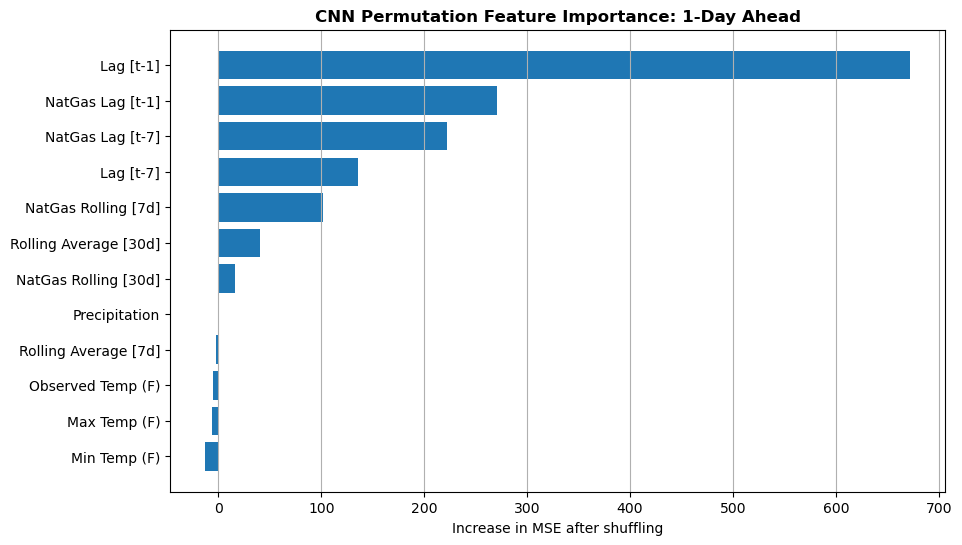

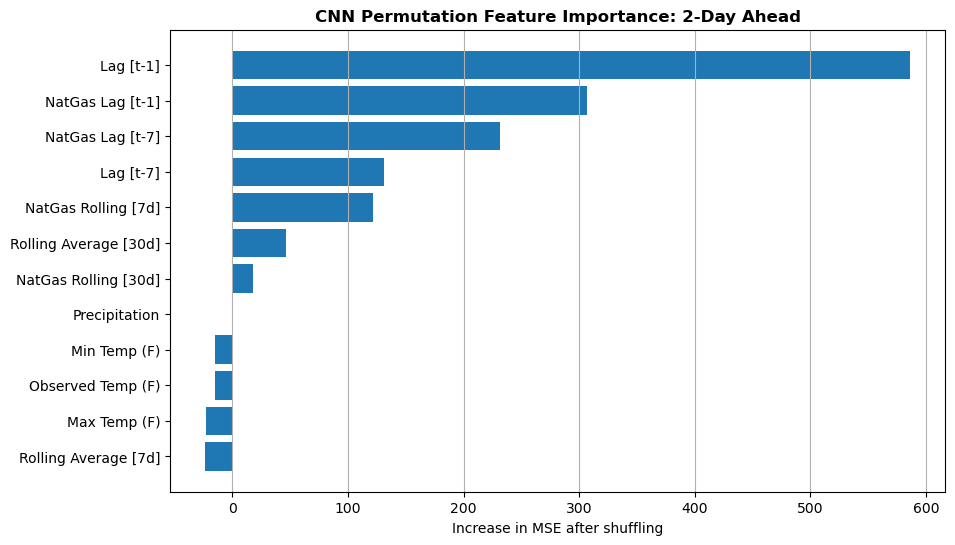

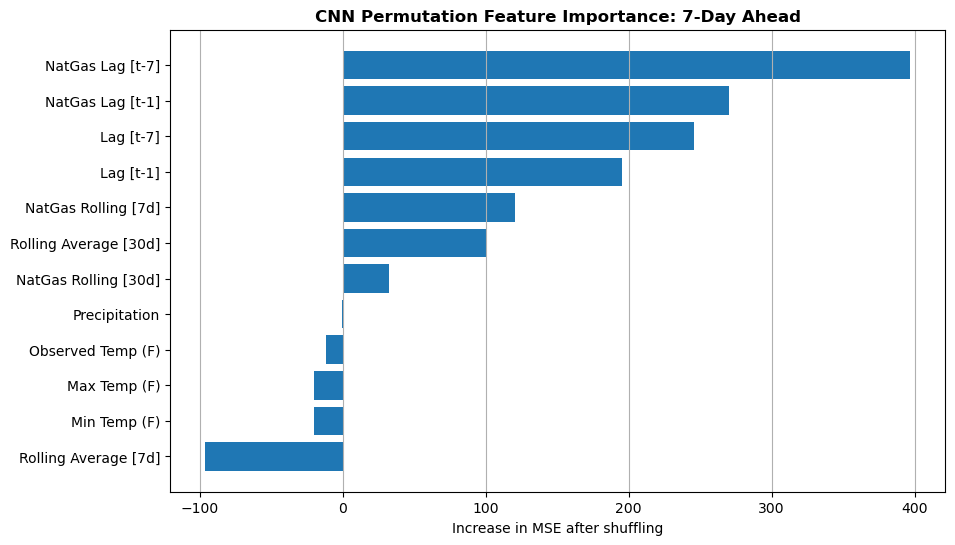

,Model,Horizon,MAE,RMSE,R-squared
0,CNN,1,13.594015,23.726226,0.773269
1,Random Forest,1,12.553748,27.470339,0.695586
2,CNN,2,14.228644,26.136702,0.724846
3,Random Forest,2,13.412378,29.233674,0.655250
4,CNN,7,18.854057,33.917610,0.536693
5,Random Forest,7,14.971125,31.444861,0.601458


,Model,Horizon,Spike Threshold,Spike Days,Spike MAE,Spike RMSE,Normal MAE,Normal RMSE
0,CNN,1,86.209999,117,40.235264,61.437653,10.635406,14.314141
1,Random Forest,1,86.209999,117,48.640618,78.031544,7.242221,10.333380
2,CNN,2,86.106999,117,44.361938,70.061960,10.865912,14.547038
3,Random Forest,2,86.106999,117,55.327802,85.446167,8.450262,11.615095
4,CNN,7,85.798000,117,58.985413,91.607540,14.373744,18.491899
5,Random Forest,7,85.798000,117,59.337240,89.534150,9.666465,13.653854


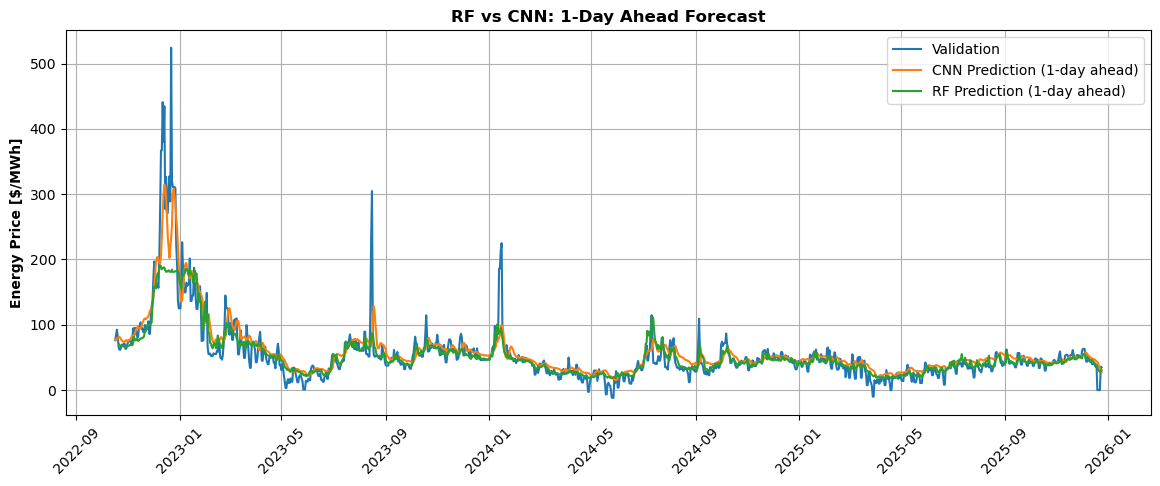

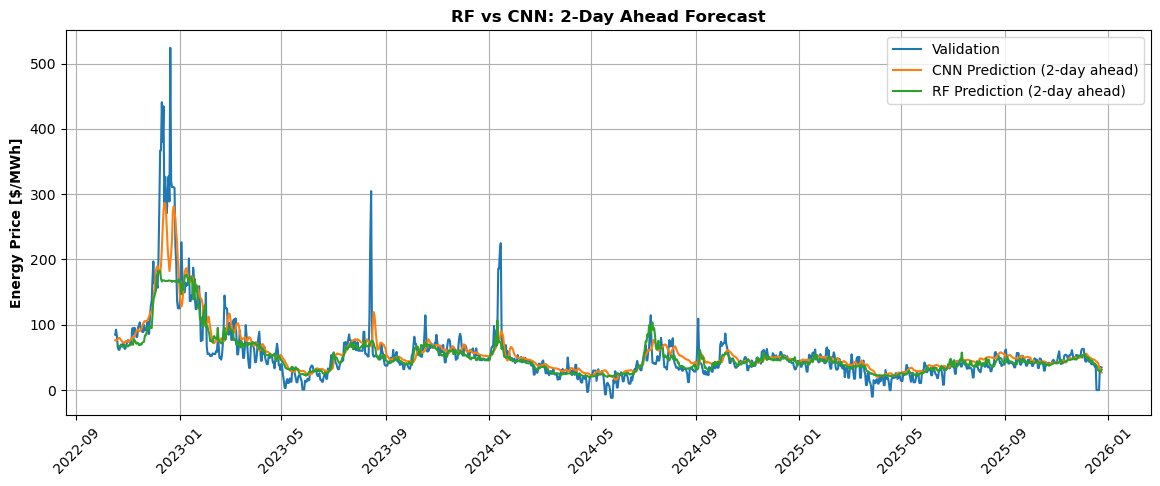

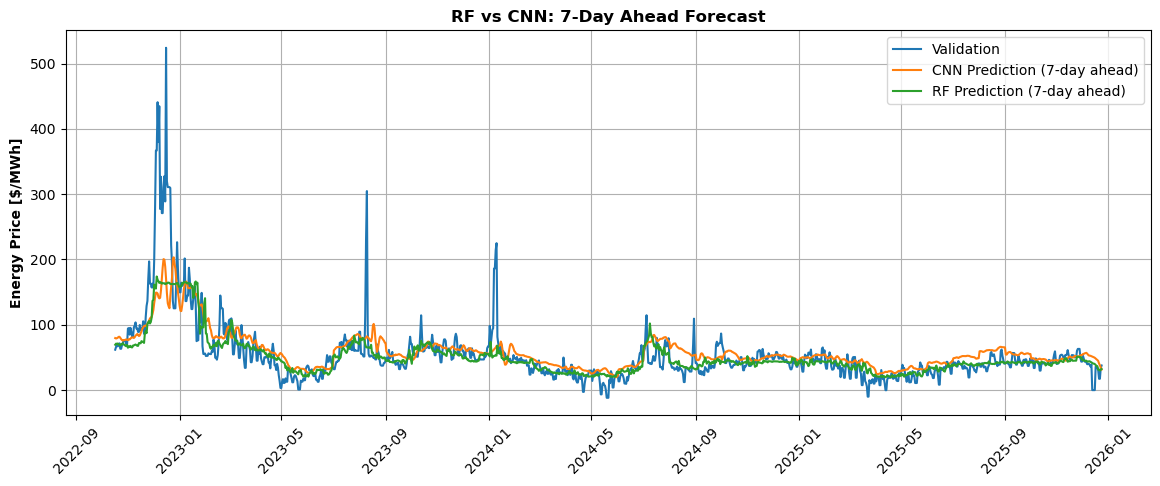

In [57]:
###############################################################
# Settings
###############################################################

horizons = [1, 2, 7]
window = 7
horizon = 7

###############################################################
# Random Forest: 1, 2, 7 days ahead
###############################################################

rf_metrics = []
rf_predictions = {}
rf_actuals = {}

for h in horizons:

    df_rf = combined_df.copy()
    df_rf["Target"] = df_rf["PX_LAST"].shift(-h)
    df_rf = df_rf.dropna()

    X_rf = df_rf.drop(columns=["PX_LAST", "Target", "Target PX_LAST [t+1]"], errors="ignore")
    y_rf = df_rf["Target"]

    X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
        X_rf,
        y_rf,
        test_size=0.2,
        shuffle=False
    )

    rf_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=2,
        min_samples_split=5,
        max_features="sqrt",
        random_state=42,
        oob_score=True,
        n_jobs=-1
    )

    rf_model.fit(X_train_rf, y_train_rf)

    ###############################################################
    # RF Feature Importance
    ###############################################################

    rf_importance = pd.DataFrame({
        "Feature": X_train_rf.columns,
        "Importance": rf_model.feature_importances_
    })

    rf_importance = rf_importance.sort_values("Importance", ascending=False)

    plt.figure(figsize=(10,6))
    plt.barh(
        rf_importance["Feature"].head(15)[::-1],
        rf_importance["Importance"].head(15)[::-1]
    )
    plt.title(f"RF Feature Importance: {h}-Day Ahead", fontweight="semibold")
    plt.xlabel("Importance")
    plt.grid(axis="x")
    plt.show()

    rf_pred = rf_model.predict(X_test_rf)

    rf_predictions[h] = pd.Series(rf_pred, index=y_test_rf.index)
    rf_actuals[h] = y_test_rf

    rf_metrics.append({
        "Model": "Random Forest",
        "Horizon": h,
        "MAE": mean_absolute_error(y_test_rf, rf_pred),
        "RMSE": mean_squared_error(y_test_rf, rf_pred) ** 0.5,
        "R-squared": r2_score(y_test_rf, rf_pred)
    })

###############################################################
# CNN: Create windows with PX_LAST excluded from input
###############################################################

def create_hybrid_windows(daily_df, monthly_df, target_col="PX_LAST", window=7, horizon=7):

    X_daily = []
    X_month = []
    y = []

    daily_feature_df = daily_df.drop(columns=[target_col])
    daily_vals = daily_feature_df.values
    monthly_vals = monthly_df.values
    target_vals = daily_df[target_col].values

    n = len(daily_df)

    for i in range(n - window - horizon):
        X_daily.append(daily_vals[i:i+window].T)
        X_month.append(monthly_vals[i+window-1])
        y.append(target_vals[i+window:i+window+horizon])

    return np.array(X_daily), np.array(X_month), np.array(y), daily_feature_df.columns


X_daily, X_month, y, daily_feature_cols = create_hybrid_windows(
    df_daily,
    df_monthly,
    target_col="PX_LAST",
    window=window,
    horizon=horizon
)

n_vars_daily = X_daily.shape[1]
n_vars_monthly = X_month.shape[1]

split = int(0.8 * len(X_daily))

X_daily_train = X_daily[:split]
X_month_train = X_month[:split]
y_train_cnn = y[:split]

X_daily_val = X_daily[split:]
X_month_val = X_month[split:]
y_val_cnn = y[split:]

###############################################################
# CNN Dataset
###############################################################

class HybridClimateDataset(Dataset):
    def __init__(self, X_daily, X_month, y):
        self.X_daily = torch.tensor(X_daily, dtype=torch.float32)
        self.X_month = torch.tensor(X_month, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X_daily)

    def __getitem__(self, idx):
        return self.X_daily[idx], self.X_month[idx], self.y[idx]


train_ds = HybridClimateDataset(X_daily_train, X_month_train, y_train_cnn)
val_ds = HybridClimateDataset(X_daily_val, X_month_val, y_val_cnn)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

###############################################################
# CNN Model
###############################################################

class HybridCNN(nn.Module):
    def __init__(self, in_channels_daily, monthly_features, horizon):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels_daily, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.mlp = nn.Sequential(
            nn.Linear(monthly_features, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(64 + 32, 64),
            nn.ReLU(),
            nn.Linear(64, horizon)
        )

    def forward(self, x_daily, x_month):
        daily_latent = self.cnn(x_daily).squeeze(-1)
        month_latent = self.mlp(x_month)
        fused = torch.cat([daily_latent, month_latent], dim=1)
        return self.fc(fused)


cnn_model = HybridCNN(
    in_channels_daily=n_vars_daily,
    monthly_features=n_vars_monthly,
    horizon=horizon
)

###############################################################
# Train CNN
###############################################################

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)

epochs = 25

for epoch in range(epochs):

    cnn_model.train()
    train_loss = 0.0

    for xb_daily, xb_month, yb in train_loader:
        optimizer.zero_grad()
        pred = cnn_model(xb_daily, xb_month)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    cnn_model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb_daily, xb_month, yb in val_loader:
            pred = cnn_model(xb_daily, xb_month)
            val_loss += criterion(pred, yb).item()

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss / len(train_loader):.4f} | "
        f"Val Loss: {val_loss / len(val_loader):.4f}"
    )

###############################################################
# CNN Predictions
###############################################################

cnn_model.eval()

cnn_preds = []
cnn_actuals = []

with torch.no_grad():
    for xb_daily, xb_month, yb in val_loader:
        out = cnn_model(xb_daily, xb_month)
        cnn_preds.append(out.numpy())
        cnn_actuals.append(yb.numpy())

cnn_preds = np.vstack(cnn_preds)
cnn_actuals = np.vstack(cnn_actuals)

cnn_dates = df_daily.index[window + split : window + split + len(cnn_actuals)]

###############################################################
# CNN Permutation Feature Importance
###############################################################

X_daily_val = X_daily[split:].copy()
X_month_val = X_month[split:].copy()
y_val = y[split:].copy()

daily_feature_names = list(daily_feature_cols)

cnn_model.eval()

with torch.no_grad():
    baseline_pred = cnn_model(
        torch.tensor(X_daily_val, dtype=torch.float32),
        torch.tensor(X_month_val, dtype=torch.float32)
    ).numpy()

for h in horizons:

    col = h - 1

    baseline_loss = mean_squared_error(
        y_val[:, col],
        baseline_pred[:, col]
    )

    importance_rows = []

    for j, feature_name in enumerate(daily_feature_names):

        X_daily_perm = X_daily_val.copy()

        shuffle_idx = np.random.permutation(X_daily_perm.shape[0])
        X_daily_perm[:, j, :] = X_daily_perm[shuffle_idx, j, :]

        with torch.no_grad():
            perm_pred = cnn_model(
                torch.tensor(X_daily_perm, dtype=torch.float32),
                torch.tensor(X_month_val, dtype=torch.float32)
            ).numpy()

        perm_loss = mean_squared_error(
            y_val[:, col],
            perm_pred[:, col]
        )

        importance_rows.append({
            "Feature": feature_name,
            "Importance": perm_loss - baseline_loss
        })

    cnn_importance = pd.DataFrame(importance_rows)
    cnn_importance = cnn_importance.sort_values("Importance", ascending=False)

    plt.figure(figsize=(10,6))
    plt.barh(
        cnn_importance["Feature"].head(15)[::-1],
        cnn_importance["Importance"].head(15)[::-1]
    )
    plt.title(f"CNN Permutation Feature Importance: {h}-Day Ahead", fontweight="semibold")
    plt.xlabel("Increase in MSE after shuffling")
    plt.grid(axis="x")
    plt.show()

###############################################################
# Metrics Comparison
###############################################################

comparison_rows = rf_metrics.copy()
for h in horizons:
    col = h - 1
    comparison_rows.append({
        "Model": "CNN",
        "Horizon": h,
        "MAE": mean_absolute_error(cnn_actuals[:, col], cnn_preds[:, col]),
        "RMSE": mean_squared_error(cnn_actuals[:, col], cnn_preds[:, col]) ** 0.5,
        "R-squared": r2_score(cnn_actuals[:, col], cnn_preds[:, col])
    })
comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(["Horizon", "Model"]).reset_index(drop=True)

display(comparison_df)

###############################################################
# Spike-Only Metrics: RF vs CNN
###############################################################

spike_rows = []

for h in horizons:

    col = h - 1

    cnn_actual_h = pd.Series(cnn_actuals[:, col], index=cnn_dates)     # CNN actual/pred
    cnn_pred_h = pd.Series(cnn_preds[:, col], index=cnn_dates)

    rf_actual_h = rf_actuals[h] # RF actual/pred
    rf_pred_h = rf_predictions[h]

    common_idx = cnn_actual_h.index.intersection(rf_actual_h.index) # Use common dates so RF and CNN are compared on the same days

    actual_common = cnn_actual_h.loc[common_idx]
    cnn_pred_common = cnn_pred_h.loc[common_idx]
    rf_pred_common = rf_pred_h.loc[common_idx]

    spike_threshold = actual_common.quantile(0.90) # Define spikes using actual prices only
    spike_mask = actual_common >= spike_threshold

    for model_name, pred_common in [
        ("Random Forest", rf_pred_common),
        ("CNN", cnn_pred_common)
    ]:

        spike_rows.append({
            "Model": model_name,
            "Horizon": h,
            "Spike Threshold": spike_threshold,
            "Spike Days": int(spike_mask.sum()),
            "Spike MAE": mean_absolute_error(actual_common[spike_mask], pred_common[spike_mask]),
            "Spike RMSE": mean_squared_error(actual_common[spike_mask], pred_common[spike_mask]) ** 0.5,
            "Normal MAE": mean_absolute_error(actual_common[~spike_mask], pred_common[~spike_mask]),
            "Normal RMSE": mean_squared_error(actual_common[~spike_mask], pred_common[~spike_mask]) ** 0.5
        })

spike_comparison_df = pd.DataFrame(spike_rows)
spike_comparison_df = spike_comparison_df.sort_values(["Horizon", "Model"]).reset_index(drop=True)

display(spike_comparison_df)

###############################################################
# Plot RF vs CNN
###############################################################

for h in horizons:

    col = h - 1
    plt.figure(figsize=(14,5))
    plt.plot(cnn_dates,cnn_actuals[:, col],label=f"Validation")
    plt.plot(cnn_dates,cnn_preds[:, col],label=f"CNN Prediction ({h}-day ahead)")
    common_idx = rf_predictions[h].index.intersection(cnn_dates)
    plt.plot(common_idx,rf_predictions[h].loc[common_idx],label=f"RF Prediction ({h}-day ahead)")

    plt.title(f"RF vs CNN: {h}-Day Ahead Forecast", fontweight="semibold")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.ylabel("Energy Price [$/MWh]", fontweight="semibold")
    plt.legend()
    plt.show()

**Other Modeling Strategies**


Top Feature Importances for 1-day ahead forecast


,Feature,Importance
3,Lag [t-1],0.199298
5,Rolling Average [7d],0.173843
9,NatGas Rolling [7d],0.121251
6,Rolling Average [30d],0.099552
7,NatGas Lag [t-1],0.094143
10,NatGas Rolling [30d],0.084562
8,NatGas Lag [t-7],0.056738
4,Lag [t-7],0.051947
14,Observed Temp (F),0.033950
12,Max Temp (F),0.025210


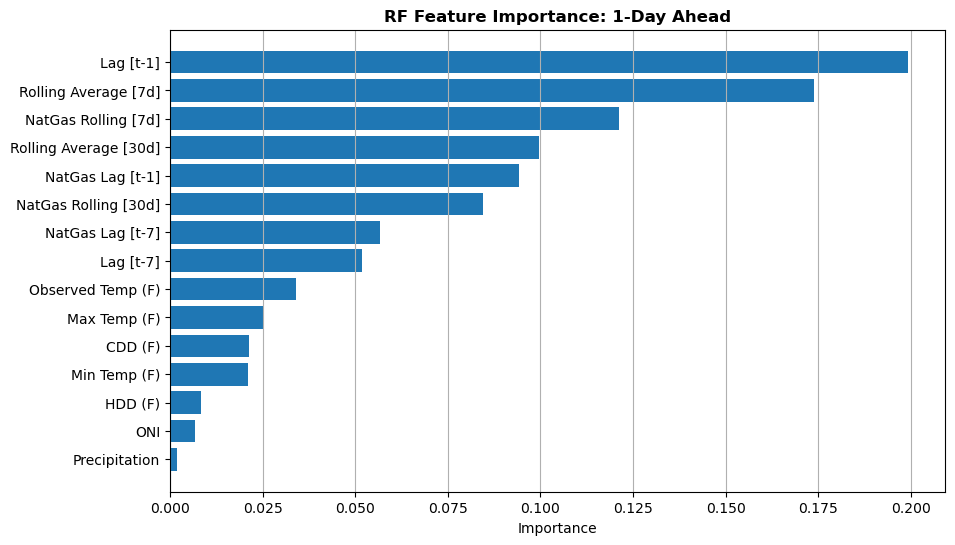


Random Forest: 1-day ahead forecast
OOB Score: 0.6623759499027145
MAE: 12.553747763020583
RMSE: 27.470338894654702
Mean Squared Error: 754.6195189871789
R-squared: 0.695585503644471


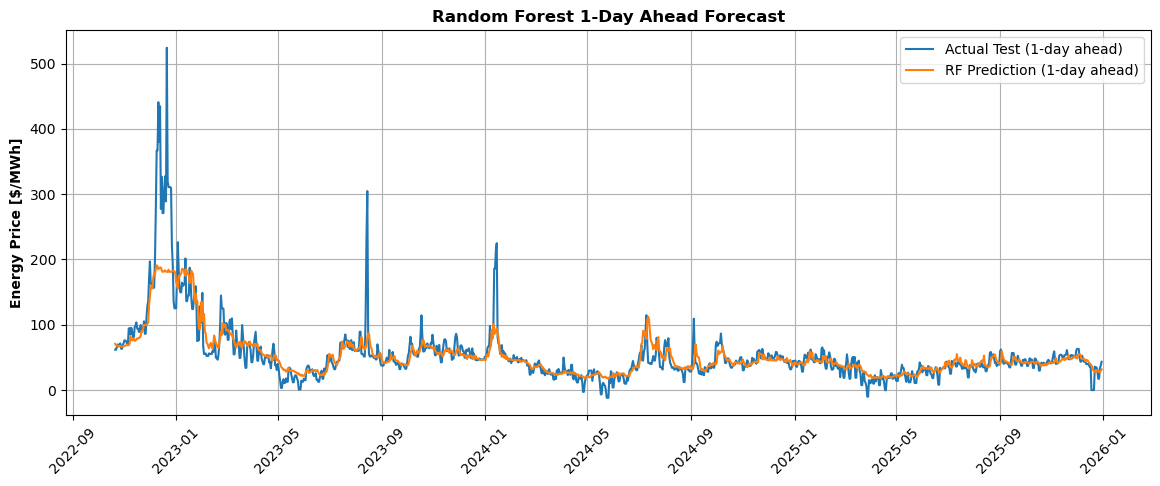

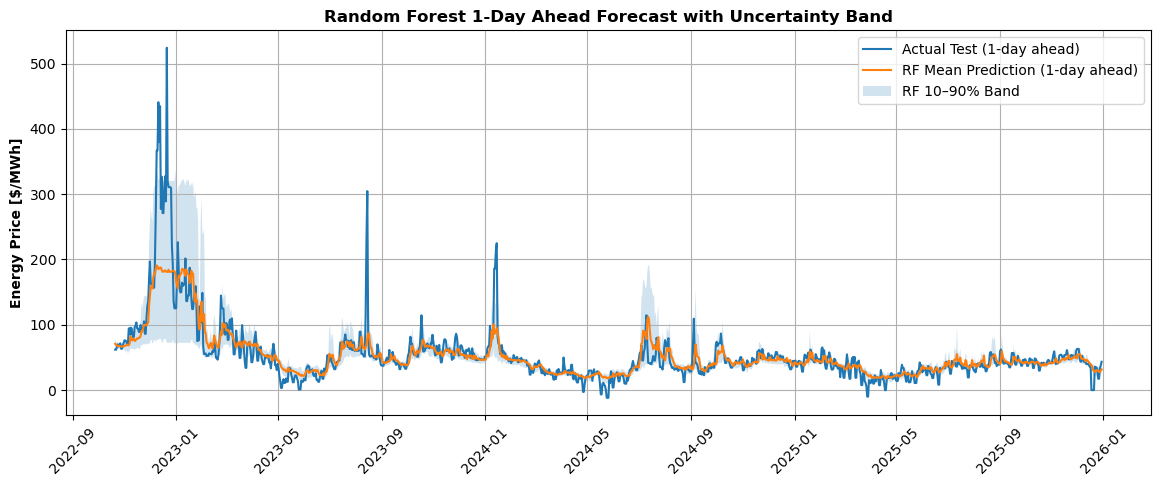


Top Feature Importances for 2-day ahead forecast


,Feature,Importance
5,Rolling Average [7d],0.160897
3,Lag [t-1],0.144316
9,NatGas Rolling [7d],0.127626
7,NatGas Lag [t-1],0.126812
6,Rolling Average [30d],0.100600
10,NatGas Rolling [30d],0.093655
8,NatGas Lag [t-7],0.078715
4,Lag [t-7],0.047009
14,Observed Temp (F),0.029171
1,CDD (F),0.028659


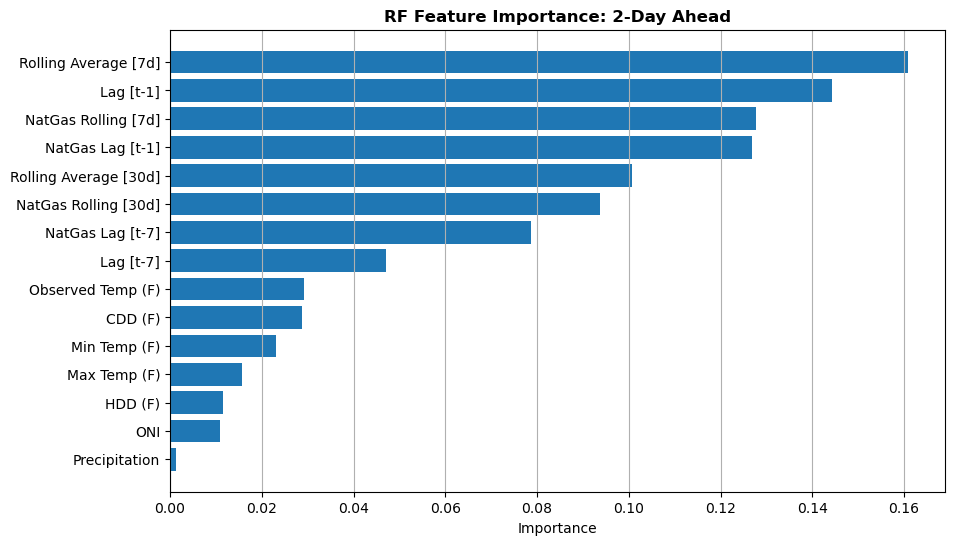


Random Forest: 2-day ahead forecast
OOB Score: 0.6557975293013338
MAE: 13.412377705862255
RMSE: 29.233673550679548
Mean Squared Error: 854.607669267701
R-squared: 0.6552501536524399


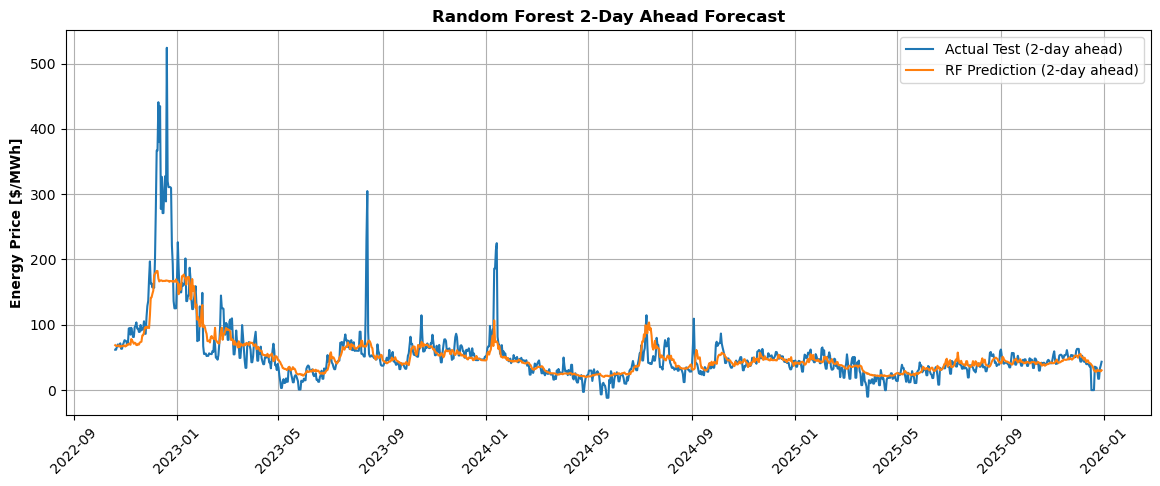

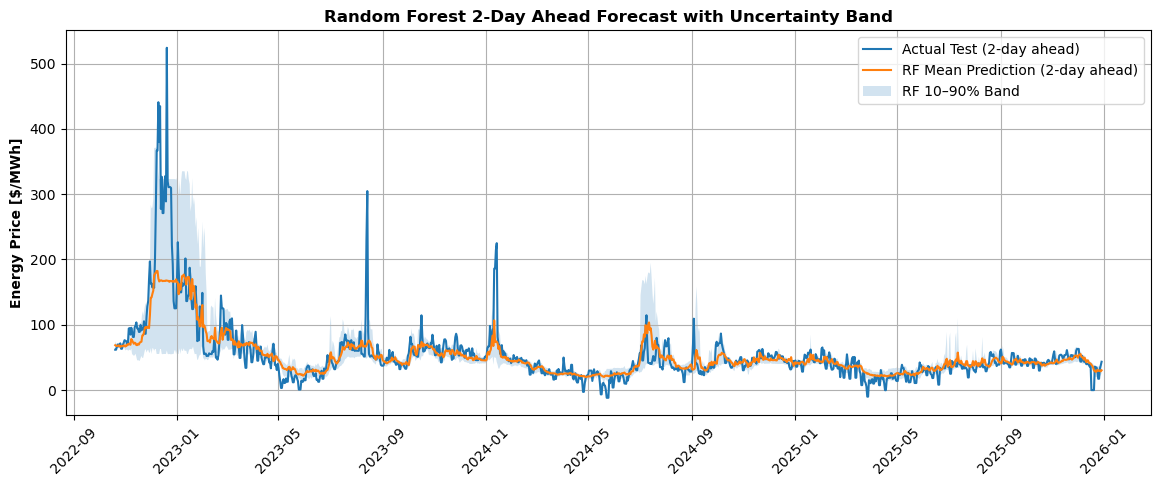


Top Feature Importances for 7-day ahead forecast


,Feature,Importance
7,NatGas Lag [t-1],0.175549
8,NatGas Lag [t-7],0.126678
9,NatGas Rolling [7d],0.109862
6,Rolling Average [30d],0.108145
4,Lag [t-7],0.093542
5,Rolling Average [7d],0.092974
3,Lag [t-1],0.068938
10,NatGas Rolling [30d],0.068597
1,CDD (F),0.063726
0,HDD (F),0.027471


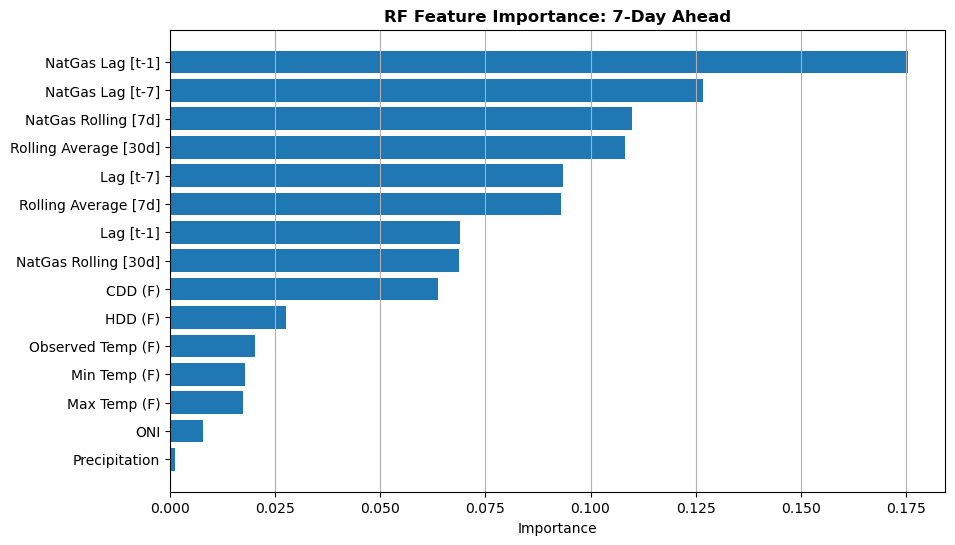


Random Forest: 7-day ahead forecast
OOB Score: 0.6638571127650137
MAE: 14.97112537551577
RMSE: 31.44486114171433
Mean Squared Error: 988.7792922216959
R-squared: 0.6014576658472726


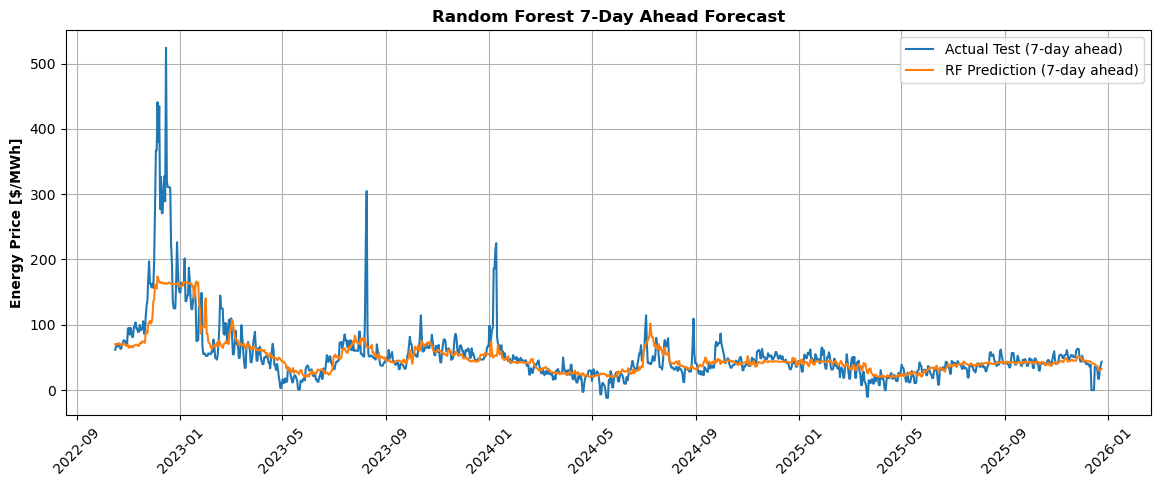

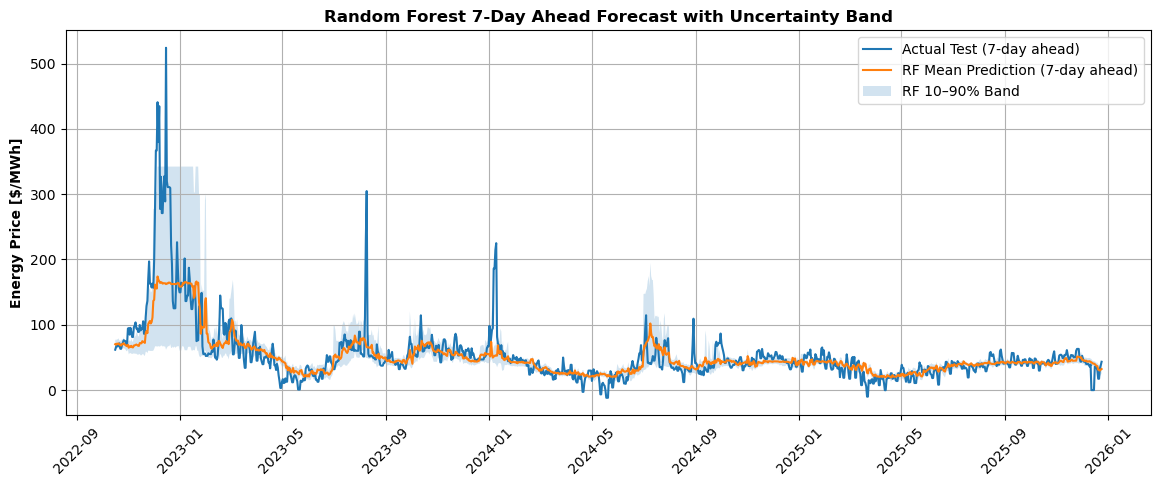

,Horizon,OOB Score,MAE,RMSE,MSE,R-squared
0,1,0.662376,12.553748,27.470339,754.619519,0.695586
1,2,0.655798,13.412378,29.233674,854.607669,0.655250
2,7,0.663857,14.971125,31.444861,988.779292,0.601458


In [59]:
######################################################
# Random Forest: 1-day, 2-day, and 7-day Ahead Forecasts
######################################################

horizons = [1, 2, 7]
models = {}
predictions = {}
actuals = {}
metrics = []

for h in horizons:

    ######################################################
    # Dataframe for each horizon
    ######################################################

    df_rf_h=combined_df.copy()
    df_rf_h["Target"] = df_rf_h["PX_LAST"].shift(-h)  # Target = price h days ahead
    df_rf_h = df_rf_h.dropna() # Drop missing values
    x_rf_h = df_rf_h.drop(columns=["PX_LAST", "Target", "Target PX_LAST [t+1]"], errors="ignore")  # X = features only, no actual price and no target columns
    y_rf_h = df_rf_h["Target"]

    ######################################################
    # Train/test split
    ######################################################

    X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(x_rf_h,y_rf_h,test_size=0.2,shuffle=False)

    ######################################################
    # Random Forest model
    ######################################################

    rf_h = RandomForestRegressor(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=2,
        min_samples_split=5,
        max_features="sqrt",
        random_state=42,
        oob_score=True,
        n_jobs=-1
    )

    rf_h.fit(X_train_h, y_train_h)

    ######################################################
    # Feature Importance
    ######################################################

    feature_importance_h = pd.DataFrame({
        "Feature": X_train_h.columns,
        "Importance": rf_h.feature_importances_
    })

    feature_importance_h = feature_importance_h.sort_values(
        by="Importance",
        ascending=False
    )

    print(f"\nTop Feature Importances for {h}-day ahead forecast")
    display(feature_importance_h.head(15))

    plt.figure(figsize=(10,6))
    plt.barh(
        feature_importance_h["Feature"].head(15)[::-1],
        feature_importance_h["Importance"].head(15)[::-1]
    )

    plt.title(f"RF Feature Importance: {h}-Day Ahead", fontweight="semibold")
    plt.xlabel("Importance")
    plt.grid(axis="x")
    plt.show()

    ######################################################
    # Metrics
    ######################################################

    pred_h = rf_h.predict(X_test_h)
    mse_h = mean_squared_error(y_test_h, pred_h)
    rmse_h = mse_h ** 0.5
    mae_h = mean_absolute_error(y_test_h, pred_h)
    r2_h = r2_score(y_test_h, pred_h)

    print("\n================================================")
    print(f"Random Forest: {h}-day ahead forecast")
    print("OOB Score:", rf_h.oob_score_)
    print("MAE:", mae_h)
    print("RMSE:", rmse_h)
    print("Mean Squared Error:", mse_h)
    print("R-squared:", r2_h)

    models[h] = rf_h
    predictions[h] = pd.Series(pred_h, index=y_test_h.index)
    actuals[h] = y_test_h

    metrics.append({
        "Horizon": h,
        "OOB Score": rf_h.oob_score_,
        "MAE": mae_h,
        "RMSE": rmse_h,
        "MSE": mse_h,
        "R-squared": r2_h
    })

    ######################################################
    # Plot forecast
    ######################################################

    plt.figure(figsize=(14,5))
    plt.plot(y_test_h.index, y_test_h, label=f"Actual Test ({h}-day ahead)")
    plt.plot(y_test_h.index, pred_h, label=f"RF Prediction ({h}-day ahead)")

    plt.title(f"Random Forest {h}-Day Ahead Forecast", fontweight="semibold")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.ylabel("Energy Price [$/MWh]", fontweight="semibold")
    plt.legend()
    plt.show()

    ######################################################
    # Uncertainty band from tree disagreement
    ######################################################

    tree_predictions = []

    for tree in rf_h.estimators_:
        tree_pred = tree.predict(X_test_h)
        tree_predictions.append(tree_pred)

    tree_preds = np.array(tree_predictions)

    q10_pred = np.percentile(tree_preds, 10, axis=0)
    q90_pred = np.percentile(tree_preds, 90, axis=0)

    plt.figure(figsize=(14,5))
    plt.plot(y_test_h.index, y_test_h, label=f"Actual Test ({h}-day ahead)")
    plt.plot(y_test_h.index, pred_h, label=f"RF Mean Prediction ({h}-day ahead)")
    plt.fill_between(y_test_h.index, q10_pred, q90_pred, alpha=0.2, label="RF 10–90% Band")

    plt.title(f"Random Forest {h}-Day Ahead Forecast with Uncertainty Band", fontweight="semibold")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.ylabel("Energy Price [$/MWh]", fontweight="semibold")
    plt.legend()
    plt.show()

######################################################
# Metrics Table
######################################################

metrics_df = pd.DataFrame(metrics)
display(metrics_df)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5835 entries, 2010-01-09 to 2025-12-30
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PX_LAST                5835 non-null   float64
 1   Lag [t-1]              5835 non-null   float64
 2   Lag [t-7]              5835 non-null   float64
 3   Rolling Average [7d]   5835 non-null   float64
 4   Rolling Average [30d]  5835 non-null   float64
 5   NatGas Lag [t-1]       5835 non-null   float64
 6   NatGas Lag [t-7]       5835 non-null   float64
 7   NatGas Rolling [7d]    5835 non-null   float64
 8   NatGas Rolling [30d]   5835 non-null   float64
 9   Precipitation          5835 non-null   float64
 10  Max Temp (F)           5835 non-null   float64
 11  Min Temp (F)           5835 non-null   float64
 12  Observed Temp (F)      5835 non-null   float64
 13  Target                 5835 non-null   float64
dtypes: float64(14)
memory usage: 683.8 KB


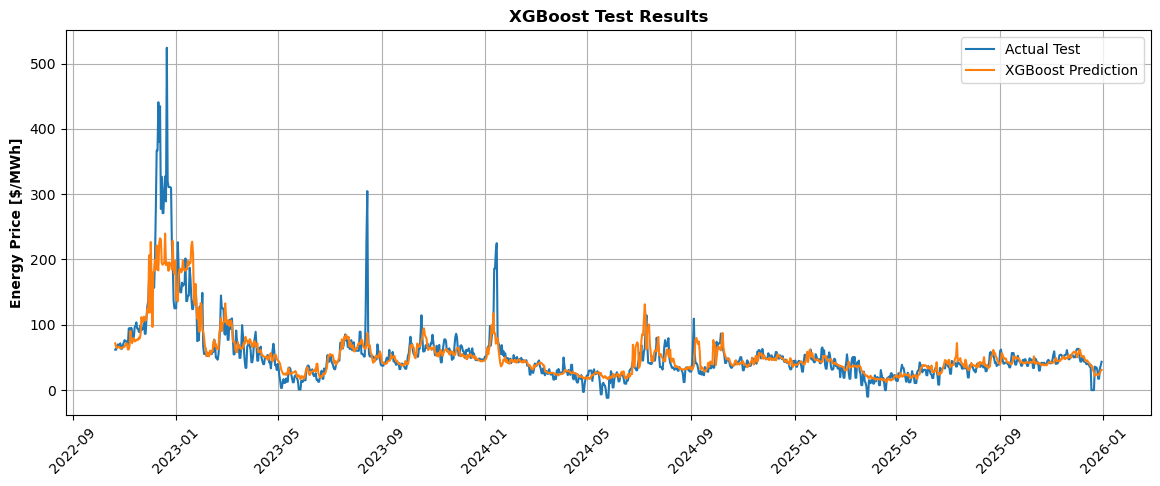

In [60]:
######################################################
# XGBoost Model for Comparison
######################################################

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import re

######################################################
# Clean column names for XGBoost
######################################################

df_rf = df_daily.copy()
df_rf["Target"] = df_rf["PX_LAST"].shift(-1)
df_rf = df_rf.dropna()

df_rf.info()

x_rf = df_rf.drop(columns=["PX_LAST", "Target", "Target PX_LAST [t+1]"], errors="ignore")
y_rf = df_rf["Target"]

######################################################
# Model Regression
######################################################
encoder = LabelEncoder()
for col in df_rf.select_dtypes(include=['object']).columns: df_rf[col]

X_train, X_test, y_train, y_test = train_test_split(x_rf, y_rf, test_size=0.2, shuffle=False)
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

def clean_xgb_col(col):
    col = str(col)
    col = re.sub(r"[\[\]<>]", "", col)
    col = col.replace(" ", "_")
    col = col.replace("(", "")
    col = col.replace(")", "")
    col = col.replace("/", "_")
    return col

new_cols = [clean_xgb_col(col) for col in X_train_xgb.columns]

X_train_xgb.columns = new_cols
X_test_xgb.columns = new_cols

######################################################
# Model
######################################################

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_xgb, y_train)

######################################################
# Summary Statistics
######################################################

xgb_pred = xgb_model.predict(X_test_xgb)

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = xgb_mse ** 0.5
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost Mean Squared Error:", xgb_mse)
print("XGBoost R-squared:", xgb_r2)

######################################################
# Results/Plotting
######################################################

plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test, label="Actual Test")
plt.plot(y_test.index, xgb_pred, label="XGBoost Prediction")

plt.title("XGBoost Test Results", fontweight="semibold")
plt.grid(True)
plt.xticks(rotation=45)
plt.ylabel("Energy Price [$/MWh]", fontweight="semibold")
plt.legend()
plt.show()

Epoch 01 | Train Loss: 383.1344 | Val Loss: 3191.9827
Epoch 02 | Train Loss: 528.8350 | Val Loss: 2239.9806
Epoch 03 | Train Loss: 517.7856 | Val Loss: 2264.8944
Epoch 04 | Train Loss: 510.7914 | Val Loss: 2265.0918
Epoch 05 | Train Loss: 502.8655 | Val Loss: 2464.8195
Epoch 06 | Train Loss: 497.0570 | Val Loss: 2269.3745
Epoch 07 | Train Loss: 498.8191 | Val Loss: 2268.3464
Epoch 08 | Train Loss: 494.5140 | Val Loss: 2269.4929
Epoch 09 | Train Loss: 490.5435 | Val Loss: 2269.8534
Epoch 10 | Train Loss: 486.8287 | Val Loss: 2273.5542
Epoch 11 | Train Loss: 483.1756 | Val Loss: 2274.9740
Epoch 12 | Train Loss: 480.2104 | Val Loss: 2273.2447
Epoch 13 | Train Loss: 477.3176 | Val Loss: 2270.3475
Epoch 14 | Train Loss: 474.0191 | Val Loss: 2277.9516
Epoch 15 | Train Loss: 470.7021 | Val Loss: 2279.7581
Epoch 16 | Train Loss: 469.0060 | Val Loss: 2282.6444
Epoch 17 | Train Loss: 466.8663 | Val Loss: 2284.6368
Epoch 18 | Train Loss: 465.1417 | Val Loss: 2288.8504
Epoch 19 | Train Loss: 463.8

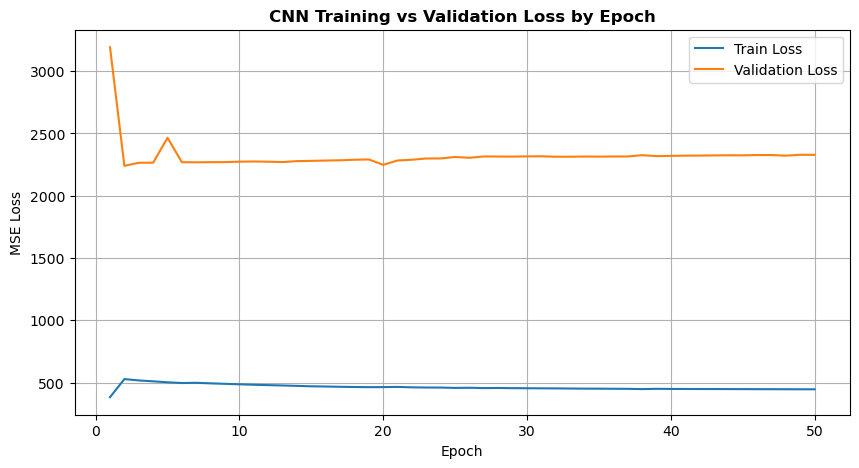

Best epoch based on validation loss: 2
Lowest validation loss: 2239.9806095844992


In [61]:
###############################################################
# Train CNN + Track Loss by Epoch
###############################################################

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)

epochs = 50

train_losses = []
val_losses = []

for epoch in range(epochs):

    cnn_model.train()
    train_loss = 0.0

    for xb_daily, xb_month, yb in train_loader:
        optimizer.zero_grad()
        pred = cnn_model(xb_daily, xb_month)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    cnn_model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb_daily, xb_month, yb in val_loader:
            pred = cnn_model(xb_daily, xb_month)
            loss = criterion(pred, yb)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

###############################################################
# Plot Loss by Epoch
###############################################################

plt.figure(figsize=(10,5))
plt.plot(range(1, epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")

plt.title("CNN Training vs Validation Loss by Epoch", fontweight="semibold")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()

best_epoch = np.argmin(val_losses) + 1
print("Best epoch based on validation loss:", best_epoch)
print("Lowest validation loss:", min(val_losses))